# SiftOps — Evaluation Analysis

University NLP Project — Retrieval-Augmented Generation over Company Policy Documents

This notebook:
1. Loads per-question results and aggregate metrics
2. Displays summary tables
3. Plots category accuracy
4. Plots retrieval comparison (BM25 vs Dense)
5. Plots failure distribution
6. Exports publication-quality figures (300 dpi PNG + vector PDF)


In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────────────────────────────────────

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

# ─────────────────────────────────────────────────────────────────────────────
# Project paths
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_ROOT = Path.cwd().resolve()

# If notebook is executed from evaluation/
if PROJECT_ROOT.name == "evaluation":
    PROJECT_ROOT = PROJECT_ROOT.parent

EVAL_DIR = PROJECT_ROOT / "evaluation"
FIGS_DIR = EVAL_DIR / "figures"

FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Make project root importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation directory: {EVAL_DIR}")
print(f"Figures directory: {FIGS_DIR}")

# ─────────────────────────────────────────────────────────────────────────────
# Files
# ─────────────────────────────────────────────────────────────────────────────

RESULTS_CSV = EVAL_DIR / "results.csv"
METRICS_JSON = EVAL_DIR / "metrics.json"
FAILURES_CSV = EVAL_DIR / "failures.csv"
COMPARE_CSV = EVAL_DIR / "comparison.csv"

print(f"Results CSV exists: {RESULTS_CSV.exists()}")
print(f"Metrics JSON exists: {METRICS_JSON.exists()}")
print(f"Failures CSV exists: {FAILURES_CSV.exists()}")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 300

Project root: /Users/attiaamaly/Desktop/NLP Project
Evaluation directory: /Users/attiaamaly/Desktop/NLP Project/evaluation
Figures directory: /Users/attiaamaly/Desktop/NLP Project/evaluation/figures
Results CSV exists: True
Metrics JSON exists: True
Failures CSV exists: True


In [2]:
# ── Plot style ─────────────────────────────────────────────────────────────
# Publication-quality defaults
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'legend.frameon':    False,
})

# Colour palette — professional, colourblind-friendly
PALETTE = {
    'dense':    '#2563EB',   # blue
    'bm25':     '#F59E0B',   # amber
    'correct':  '#10B981',   # emerald
    'failure':  '#EF4444',   # red
    'neutral':  '#6B7280',   # gray
    'hit1':     '#1D4ED8',
    'hit5':     '#93C5FD',
}

CAT_COLOURS = sns.color_palette('muted', 10)
print('Style configured.')

Style configured.


---
## 1. Load Results


In [3]:
# ── Load per-question results ──────────────────────────────────────────────
results_path = EVAL_DIR / 'results.csv'
assert results_path.exists(), (
    f'results.csv not found at {results_path}.\n'
    'Run: python evaluation/run_evaluation.py'
)

results_df = pd.read_csv(results_path)

# Normalise boolean columns that may be stored as strings
for col in ['is_out_of_scope', 'hit_at_1', 'hit_at_5', 'search_success',
            'chat_success', 'refused', 'source_match']:
    if col in results_df.columns:
        results_df[col] = results_df[col].astype(str).str.lower().isin(['true', '1', 'yes'])

print(f'Loaded {len(results_df)} rows from results.csv')
results_df.head(5)

Loaded 35 rows from results.csv


,question_id,question,expected_document,category,is_out_of_scope,search_success,retrieved_top1,retrieved_sources,hit_at_1,hit_at_5,chat_success,answer_preview,refused,source_match,error_category
0,1,What is the meal reimbursement limit for lunch?,Finance_Expenses_Policy,Exact,False,True,Finance_Expenses_Policy.pdf,Finance_Expenses_Policy.pdf|Finance_Travel_Pol...,True,True,True,"Based on Finance_Expenses_Policy.pdf, Expenses...",False,True,Correct
1,2,What is the meal reimbursement limit for dinner?,Finance_Expenses_Policy,Exact,False,True,Finance_Expenses_Policy.pdf,Finance_Expenses_Policy.pdf|Finance_Travel_Pol...,True,True,True,"Based on Finance_Expenses_Policy.pdf, Expenses...",False,True,Correct
2,3,How long do employees have to submit expenses?,Finance_Expenses_Policy,Exact,False,True,Finance_Expenses_Policy.pdf,Finance_Expenses_Policy.pdf|Finance_Invoice_Pr...,True,True,True,"Based on Finance_Expenses_Policy.pdf, Expenses...",False,True,Correct
3,4,What is the default per diem amount?,Finance_Travel_Policy,Exact,False,True,Finance_Travel_Policy.pdf,Finance_Travel_Policy.pdf|Finance_Expenses_Pol...,True,True,True,"Based on Finance_Travel_Policy.pdf, Travel Pol...",False,True,Correct
4,5,How often are invoices processed?,Finance_Invoice_Processing_SOP,Exact,False,True,Finance_Invoice_Processing_SOP.pdf,Finance_Invoice_Processing_SOP.pdf|Finance_Ven...,True,True,True,"Based on Finance_Invoice_Processing_SOP.pdf, I...",False,True,Correct


---
## 2. Load Metrics


In [4]:
# ── Load metrics.json ──────────────────────────────────────────────────────
metrics_path = EVAL_DIR / 'metrics.json'
assert metrics_path.exists(), (
    f'metrics.json not found at {metrics_path}.\n'
    'Run: python evaluation/run_evaluation.py'
)

with open(metrics_path) as f:
    metrics = json.load(f)

print('Metrics keys:', list(metrics.keys()))
print(json.dumps(metrics.get('overall', {}), indent=2))

Metrics keys: ['overall', 'per_category', 'error_distribution']
{
  "total_questions": 35,
  "in_scope_questions": 30,
  "out_of_scope_questions": 5,
  "search_success_rate": 1.0,
  "chat_success_rate": 1.0,
  "hit_at_1": 0.8,
  "hit_at_5": 0.9,
  "refusal_accuracy": 0.0,
  "source_match_rate": 0.9
}


---
## 3. Display Summary Tables


In [5]:
# ── Overall metrics table ──────────────────────────────────────────────────
ov = metrics.get('overall', {})

def fmt_metric(v):
    if v is None:
        return 'N/A'
    if isinstance(v, float) and v <= 1.0:
        return f'{v:.1%}'
    return str(v)

overall_table = pd.DataFrame([
    {'Metric': k.replace('_', ' ').title(), 'Value': fmt_metric(v)}
    for k, v in ov.items()
])

print('=== Overall Evaluation Metrics ===')
display(overall_table.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])
    .hide(axis='index'))

=== Overall Evaluation Metrics ===


Metric,Value
Total Questions,35
In Scope Questions,30
Out Of Scope Questions,5
Search Success Rate,100.0%
Chat Success Rate,100.0%
Hit At 1,80.0%
Hit At 5,90.0%
Refusal Accuracy,0.0%
Source Match Rate,90.0%


In [6]:
# ── Per-category table ─────────────────────────────────────────────────────
pc = metrics.get('per_category', {})

cat_rows = []
for cat, vals in sorted(pc.items()):
    cat_rows.append({
        'Category':         cat,
        'Questions':        vals.get('count', 0),
        'Hit@1':            fmt_metric(vals.get('hit_at_1')),
        'Hit@5':            fmt_metric(vals.get('hit_at_5')),
        'Source Match Rate': fmt_metric(vals.get('source_match_rate')),
    })

cat_df = pd.DataFrame(cat_rows)
print('=== Per-Category Retrieval Performance ===')
display(cat_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])
    .hide(axis='index'))

=== Per-Category Retrieval Performance ===


Category,Questions,Hit@1,Hit@5,Source Match Rate
Acronym,5,100.0%,100.0%,100.0%
Ambiguous,4,75.0%,100.0%,100.0%
Exact,8,100.0%,100.0%,100.0%
Reasoning,5,60.0%,60.0%,60.0%
Semantic,8,62.5%,87.5%,87.5%


In [7]:
# ── Error distribution table ───────────────────────────────────────────────
err_dist = metrics.get('error_distribution', {})
if err_dist:
    err_df = (
        pd.DataFrame(err_dist.items(), columns=['Error Category', 'Count'])
          .sort_values('Count', ascending=False)
          .reset_index(drop=True)
    )
    err_df['Percentage'] = (err_df['Count'] / err_df['Count'].sum() * 100).round(1).astype(str) + '%'
    print('=== Error Distribution ===')
    display(err_df.style.hide(axis='index'))
else:
    print('No error distribution data available.')

=== Error Distribution ===


Error Category,Count,Percentage
Correct,24,68.6%
Refusal Failure,5,14.3%
Semantic Mismatch,3,8.6%
Retrieval Failure,3,8.6%


---
## 4. Plot: Category Accuracy


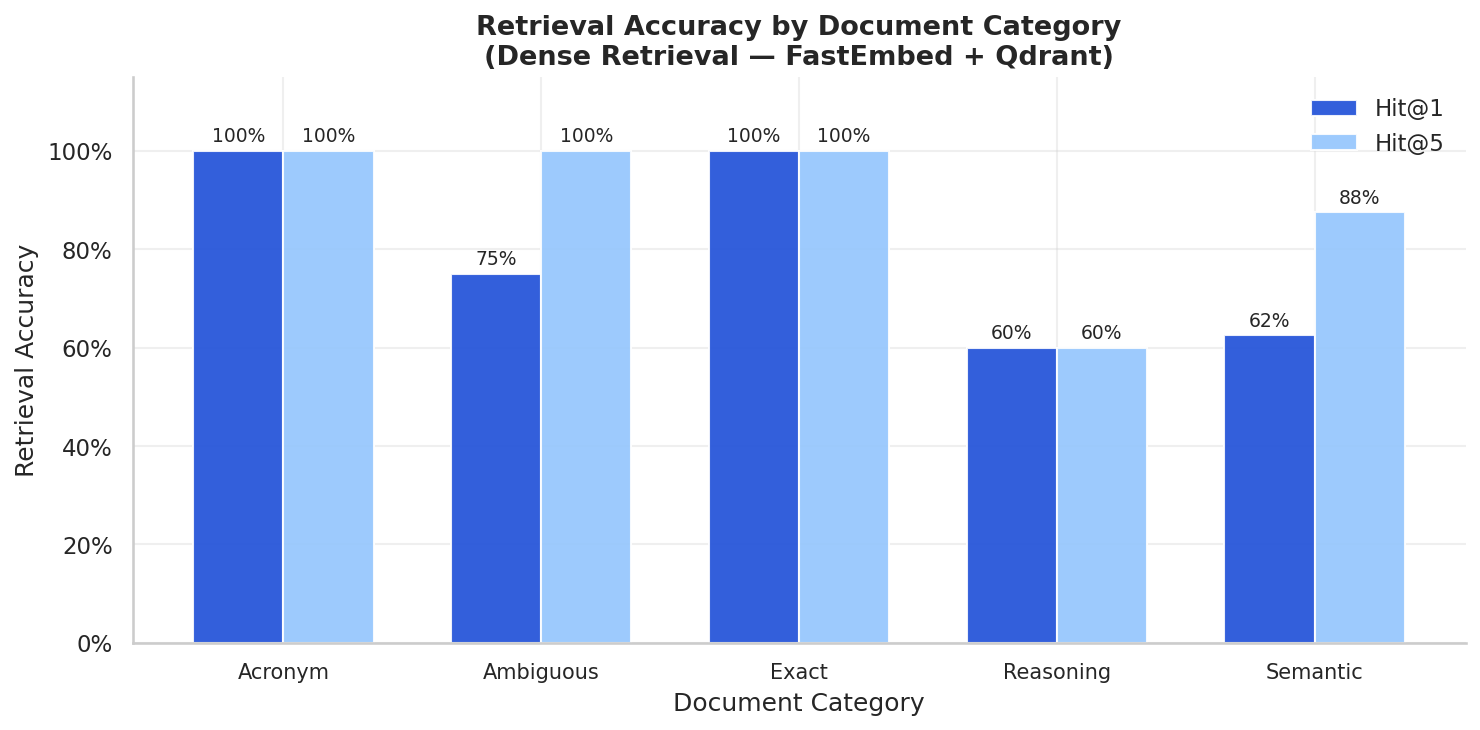

Figure saved to /Users/attiaamaly/Desktop/NLP Project/evaluation/figures/category_accuracy.png (.pdf)


In [8]:
# ── Category accuracy bar chart ────────────────────────────────────────────
pc = metrics.get('per_category', {})
if not pc:
    print('No per-category data. Skipping.')
else:
    categories  = sorted(pc.keys())
    hit1_vals   = [pc[c].get('hit_at_1', 0) or 0 for c in categories]
    hit5_vals   = [pc[c].get('hit_at_5', 0) or 0 for c in categories]

    x  = np.arange(len(categories))
    w  = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

    bars1 = ax.bar(x - w/2, hit1_vals, w,
                   label='Hit@1', color=PALETTE['hit1'], alpha=0.9)
    bars2 = ax.bar(x + w/2, hit5_vals, w,
                   label='Hit@5', color=PALETTE['hit5'], alpha=0.9)

    # Value labels on bars
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.0%}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.0%}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_', '\n') for c in categories], fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_xlabel('Document Category')
    ax.set_ylabel('Retrieval Accuracy')
    ax.set_title('Retrieval Accuracy by Document Category\n(Dense Retrieval — FastEmbed + Qdrant)',
                 fontweight='bold')
    ax.legend()

    plt.tight_layout()
    fig.savefig(FIGS_DIR / 'category_accuracy.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIGS_DIR / 'category_accuracy.pdf', bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {FIGS_DIR}/category_accuracy.png (.pdf)')

---
## 5. Plot: BM25 vs Dense Retrieval Comparison


In [9]:
# ── Load comparison.csv (may not exist if --compare wasn't run) ────────────
compare_path = EVAL_DIR / 'comparison.csv'

if not compare_path.exists():
    print('comparison.csv not found. Run: python evaluation/run_evaluation.py --compare')
    compare_df = None
else:
    compare_df = pd.read_csv(compare_path)
    for col in ['bm25_hit_at_1', 'dense_hit_at_1', 'bm25_hit_at_5', 'dense_hit_at_5']:
        if col in compare_df.columns:
            compare_df[col] = compare_df[col].astype(str).str.lower().isin(['true', '1', 'yes'])
    print(f'Loaded {len(compare_df)} rows from comparison.csv')
    display(compare_df.head(5))

comparison.csv not found. Run: python evaluation/run_evaluation.py --compare


In [10]:
# ── Grouped bar: BM25 vs Dense Hit@1 and Hit@5 ────────────────────────────
rc = metrics.get('retrieval_comparison', {})

if not rc:
    print('No retrieval_comparison data in metrics.json. Run with --compare.')
else:
    labels  = ['Hit@1', 'Hit@5']
    bm25_v  = [rc.get('bm25_hit_at_1', 0),  rc.get('bm25_hit_at_5', 0)]
    dense_v = [rc.get('dense_hit_at_1', 0), rc.get('dense_hit_at_5', 0)]

    x = np.arange(len(labels))
    w = 0.3

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: grouped bar
    ax = axes[0]
    b1 = ax.bar(x - w/2, bm25_v,  w, label='BM25',  color=PALETTE['bm25'],  alpha=0.9)
    b2 = ax.bar(x + w/2, dense_v, w, label='Dense', color=PALETTE['dense'], alpha=0.9)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title('BM25 vs Dense Retrieval\n(Hit@1 and Hit@5)', fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.legend()

    # Right: winner pie chart
    ax2 = axes[1]
    winner_counts = [
        rc.get('dense_wins', 0),
        rc.get('bm25_wins', 0),
        rc.get('both_win', 0),
        rc.get('neither_wins', 0),
    ]
    winner_labels = ['Dense Only', 'BM25 Only', 'Both Correct', 'Both Wrong']
    winner_colours = [PALETTE['dense'], PALETTE['bm25'], PALETTE['correct'], PALETTE['failure']]

    non_zero = [(l, v, c) for l, v, c in zip(winner_labels, winner_counts, winner_colours) if v > 0]
    if non_zero:
        labels_nz, vals_nz, cols_nz = zip(*non_zero)
        wedges, texts, autotexts = ax2.pie(
            vals_nz,
            labels=labels_nz,
            colors=cols_nz,
            autopct='%1.0f%%',
            startangle=90,
            pctdistance=0.75,
        )
        for at in autotexts:
            at.set_fontsize(9)
    ax2.set_title('Per-Question Winner Distribution\n(Hit@1 basis)', fontweight='bold')

    plt.tight_layout()
    fig.savefig(FIGS_DIR / 'retrieval_comparison.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIGS_DIR / 'retrieval_comparison.pdf', bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {FIGS_DIR}/retrieval_comparison.png (.pdf)')

No retrieval_comparison data in metrics.json. Run with --compare.


---
## 6. Plot: Failure Distribution


In [11]:
# ── Load failures.csv ──────────────────────────────────────────────────────
failures_path = EVAL_DIR / 'failures.csv'
if not failures_path.exists():
    print('failures.csv not found — either no failures occurred or evaluation has not run.')
    failures_df = pd.DataFrame()
else:
    failures_df = pd.read_csv(failures_path)
    print(f'Loaded {len(failures_df)} failures')
    display(failures_df[['question_id', 'question', 'expected_document',
                          'retrieved_document', 'error_category']].head(10))

Loaded 11 failures


,question_id,question,expected_document,retrieved_document,error_category
0,9,Can I work from Spain for two months?,HR_Remote_Work_Policy,Finance_Travel_Policy.pdf,Semantic Mismatch
1,12,Can my vacation request be rejected?,HR_Leave_and_Absence_Policy,Compliance_Anti_Bribery_Policy.pdf,Retrieval Failure
2,13,What should I do before signing with a new sup...,Finance_Vendor_Onboarding,Finance_Procurement_Policy.pdf,Semantic Mismatch
3,22,I want to spend €6000. Who must approve it?,Finance_Approval_Matrix + Finance_Procurement_...,Finance_Approval_Matrix.pdf,Retrieval Failure
4,26,What happens after a major incident occurs?,Security_Incident_Response_Playbook + Postmort...,Security_Incident_Response_Playbook.pdf,Retrieval Failure
5,30,What should I do when reporting concerns?,HR_Code_of_Conduct,Security_Incident_Response_Playbook.pdf,Semantic Mismatch
6,31,What is today's weather?,REFUSE,Security_Data_Classification_Standard.pdf,Refusal Failure
7,32,Should I buy Tesla stock?,REFUSE,Support_Triage_Playbook.pdf,Refusal Failure
8,33,Who won the World Cup?,REFUSE,Compliance_Anti_Bribery_Policy.pdf,Refusal Failure
9,34,What is OpenAI's valuation?,REFUSE,Eng_Architecture_Overview.pdf,Refusal Failure


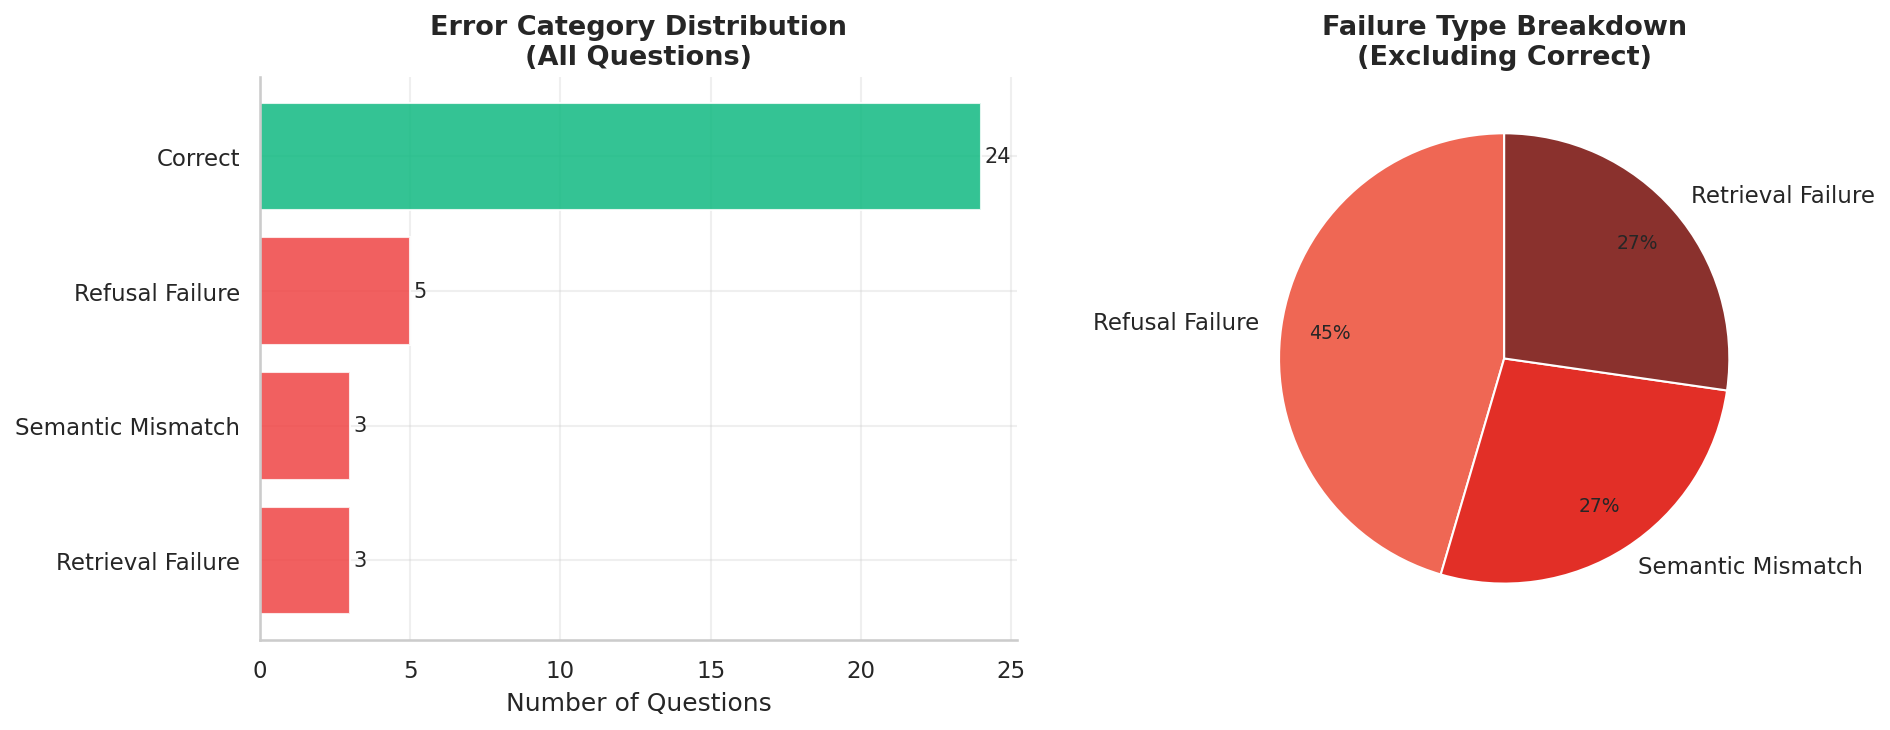

Figure saved to /Users/attiaamaly/Desktop/NLP Project/evaluation/figures/failure_distribution.png (.pdf)


In [12]:
# ── Error category distribution plots ──────────────────────────────────────
err_dist = metrics.get('error_distribution', {})

if not err_dist:
    print('No error distribution data.')
else:
    err_series = pd.Series(err_dist).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: horizontal bar chart
    ax = axes[0]
    bar_colours = [
        PALETTE['correct'] if cat == 'Correct' else PALETTE['failure']
        for cat in err_series.index
    ]
    bars = ax.barh(err_series.index, err_series.values, color=bar_colours, alpha=0.85)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.1, bar.get_y() + bar.get_height()/2,
                str(int(w)), va='center', fontsize=10)
    ax.set_xlabel('Number of Questions')
    ax.set_title('Error Category Distribution\n(All Questions)', fontweight='bold')
    ax.invert_yaxis()

    # Right: only failure categories (exclude Correct)
    ax2 = axes[1]
    failures_only = err_series[err_series.index != 'Correct']
    if not failures_only.empty:
        failure_colours = sns.color_palette('Reds_d', len(failures_only))
        wedges, texts, autotexts = ax2.pie(
            failures_only.values,
            labels=failures_only.index,
            colors=failure_colours,
            autopct='%1.0f%%',
            startangle=90,
            pctdistance=0.78,
        )
        for at in autotexts:
            at.set_fontsize(9)
        ax2.set_title('Failure Type Breakdown\n(Excluding Correct)', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No failures!', ha='center', va='center',
                 fontsize=14, color=PALETTE['correct'])
        ax2.axis('off')

    plt.tight_layout()
    fig.savefig(FIGS_DIR / 'failure_distribution.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIGS_DIR / 'failure_distribution.pdf', bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {FIGS_DIR}/failure_distribution.png (.pdf)')

---
## 7. Publication-Quality Figures


KeyError: 'hit_at_1_1'

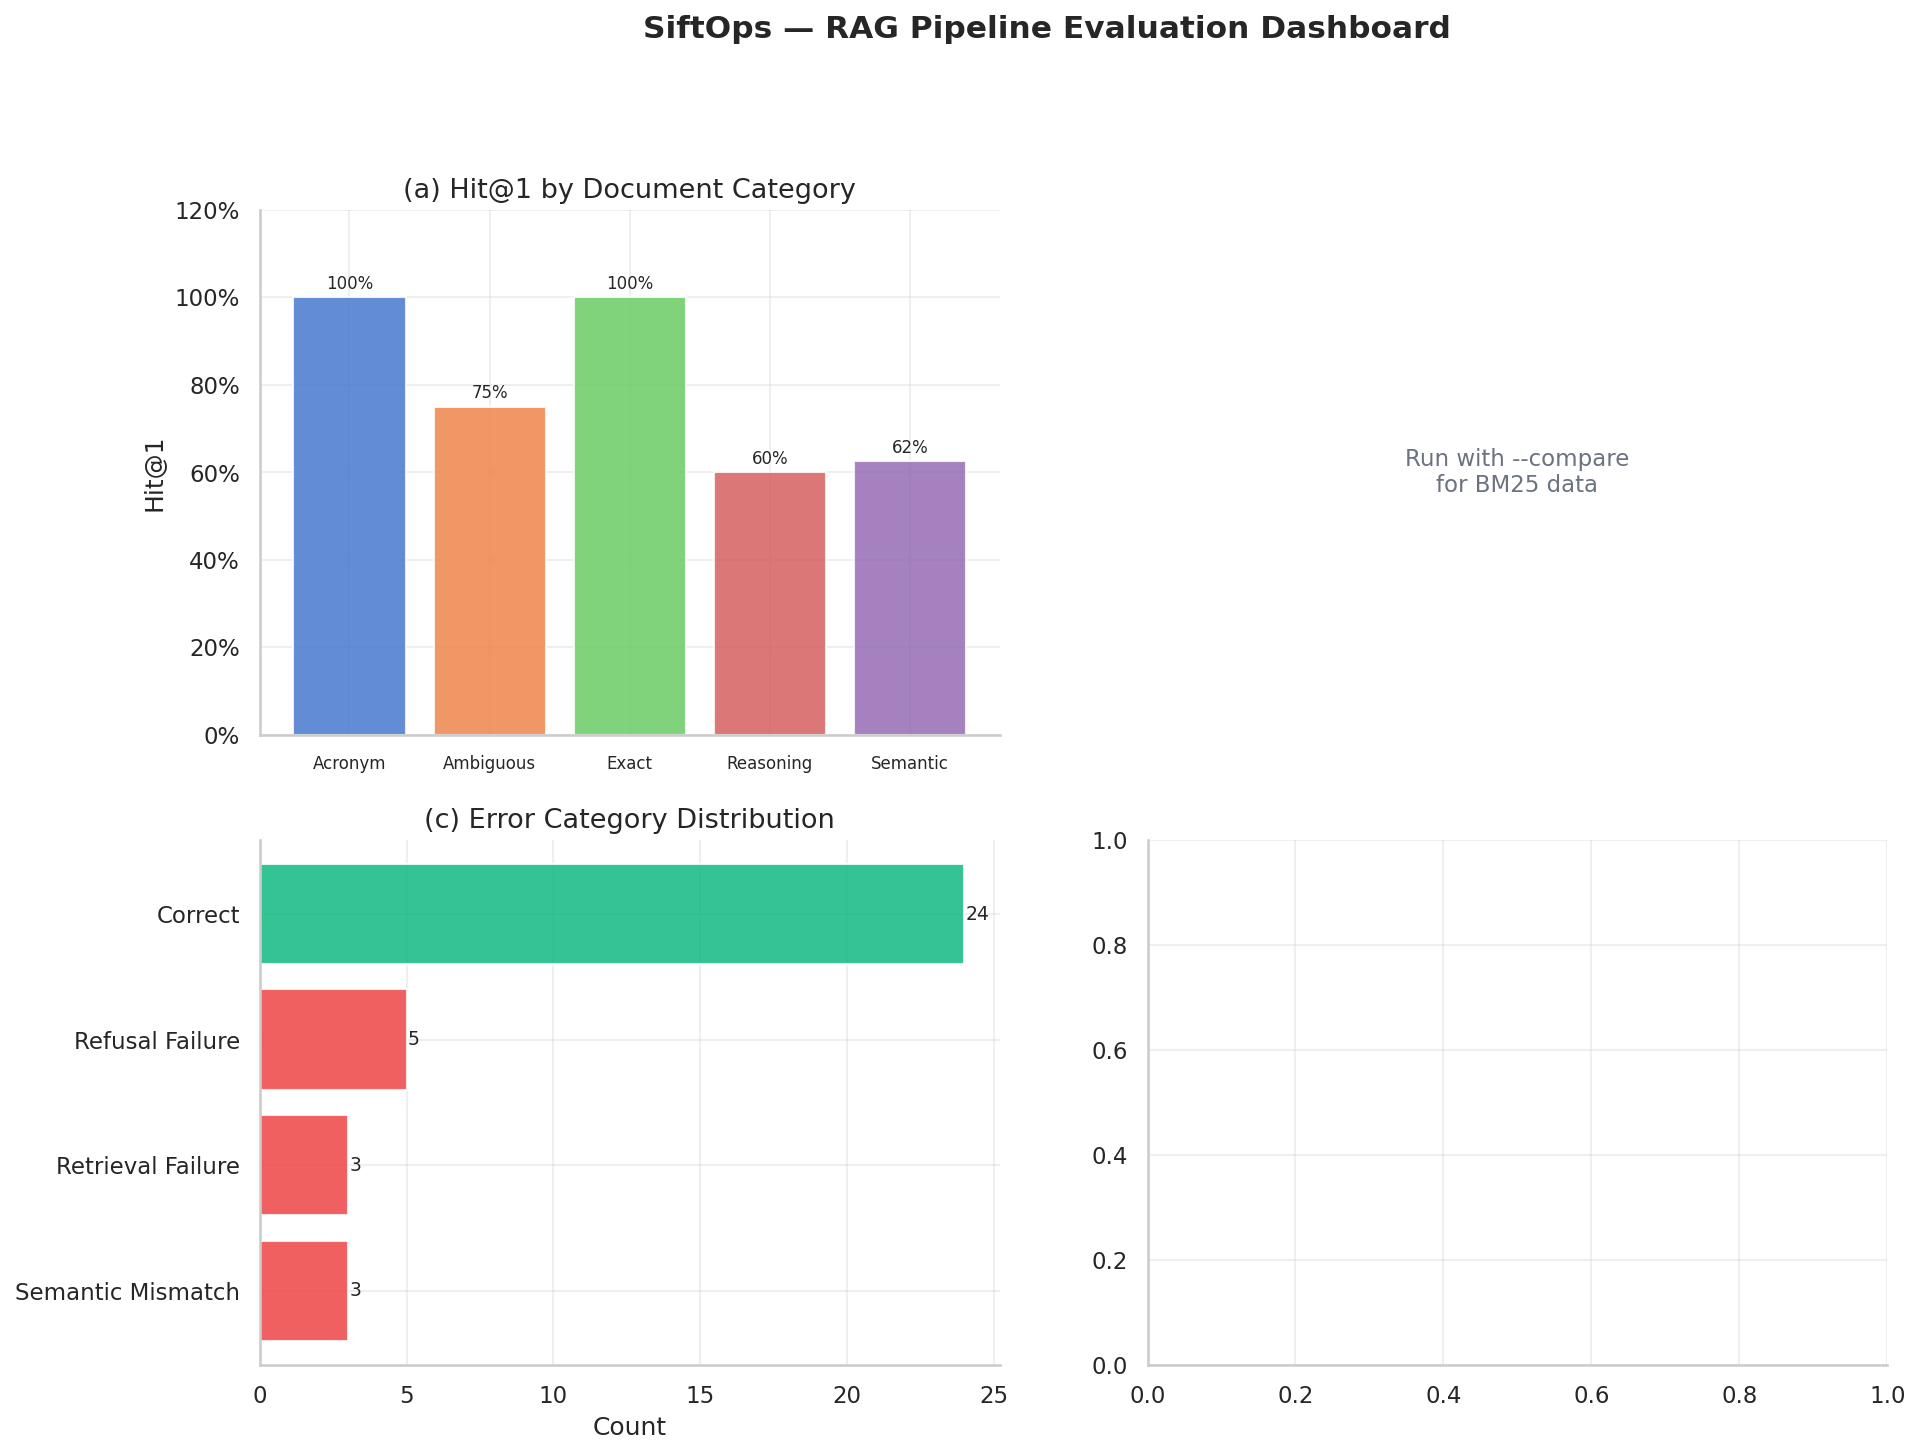

In [13]:
# ── Figure 1: Comprehensive dashboard ─────────────────────────────────────
# 2×2 grid: (a) category accuracy  (b) comparison bars
#            (c) error distribution (d) per-question scatter

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SiftOps — RAG Pipeline Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)

pc = metrics.get('per_category', {})
rc = metrics.get('retrieval_comparison', {})

# ── (a) Category Hit@1 ────────────────────────────────────────────────────
ax = axes[0, 0]
if pc:
    cats      = sorted(pc.keys())
    h1_vals   = [pc[c].get('hit_at_1', 0) or 0 for c in cats]
    bar_cols  = [CAT_COLOURS[i % len(CAT_COLOURS)] for i in range(len(cats))]
    bars = ax.bar(range(len(cats)), h1_vals, color=bar_cols, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.0%}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels([c.replace('_', '\n') for c in cats], fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title('(a) Hit@1 by Document Category')
    ax.set_ylabel('Hit@1')

# ── (b) BM25 vs Dense ─────────────────────────────────────────────────────
ax = axes[0, 1]
if rc:
    groups  = ['Hit@1', 'Hit@5']
    bm25_v  = [rc.get('bm25_hit_at_1', 0),  rc.get('bm25_hit_at_5', 0)]
    dense_v = [rc.get('dense_hit_at_1', 0), rc.get('dense_hit_at_5', 0)]
    x = np.arange(len(groups))
    w = 0.3
    ax.bar(x - w/2, bm25_v,  w, label='BM25',  color=PALETTE['bm25'],  alpha=0.9)
    ax.bar(x + w/2, dense_v, w, label='Dense', color=PALETTE['dense'], alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title('(b) BM25 vs Dense Retrieval')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Run with --compare\nfor BM25 data', ha='center', va='center',
            color=PALETTE['neutral'], fontsize=11)
    ax.axis('off')

# ── (c) Error distribution ────────────────────────────────────────────────
ax = axes[1, 0]
err_dist = metrics.get('error_distribution', {})
if err_dist:
    err_s = pd.Series(err_dist).sort_values()
    cols  = [PALETTE['correct'] if k == 'Correct' else PALETTE['failure'] for k in err_s.index]
    ax.barh(err_s.index, err_s.values, color=cols, alpha=0.85)
    for i, v in enumerate(err_s.values):
        ax.text(v + 0.05, i, str(v), va='center', fontsize=9)
    ax.set_title('(c) Error Category Distribution')
    ax.set_xlabel('Count')

# ── (d) Scatter: score vs hit@1 ───────────────────────────────────────────
ax = axes[1, 1]
in_scope_df = results_df[~results_df['is_out_of_scope']].copy() if len(results_df) > 0 else pd.DataFrame()

if not in_scope_df.empty and 'hit_at_1' in in_scope_df.columns:
    # Show distribution of hit vs no-hit per category
    cat_hit  = in_scope_df.groupby('category')['hit_at_1'].mean().reset_index()
    cat_hit5 = in_scope_df.groupby('category')['hit_at_5'].mean().reset_index()
    merged   = cat_hit.merge(cat_hit5, on='category', suffixes=('_1', '_5'))

    sc = ax.scatter(
        merged['hit_at_1_1'], merged['hit_at_5_5'],
        s=120, c=range(len(merged)),
        cmap='tab10', zorder=3, edgecolors='white', linewidths=0.8,
    )
    for _, row in merged.iterrows():
        ax.annotate(
            row['category'].replace('_', ' '),
            (row['hit_at_1_1'], row['hit_at_5_5']),
            textcoords='offset points', xytext=(5, 4), fontsize=8,
        )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, lw=1)
    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_xlabel('Hit@1')
    ax.set_ylabel('Hit@5')
    ax.set_title('(d) Hit@1 vs Hit@5 per Category')
else:
    ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', color=PALETTE['neutral'])
    ax.axis('off')

plt.tight_layout()
fig.savefig(FIGS_DIR / 'evaluation_dashboard.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGS_DIR / 'evaluation_dashboard.pdf', bbox_inches='tight')
plt.show()
print(f'Dashboard saved to {FIGS_DIR}/evaluation_dashboard.png (.pdf)')

In [14]:
# ── Summary of exported figures ────────────────────────────────────────────
print('\n=== Exported Figures ===')
for f in sorted(FIGS_DIR.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40} {size_kb:6.1f} KB')


=== Exported Figures ===
  category_accuracy.pdf                      24.9 KB
  category_accuracy.png                     139.7 KB
  failure_distribution.pdf                   23.9 KB
  failure_distribution.png                  163.2 KB
